#### Author's Information:
        Author : Ali Rizvi.
        Stu ID : 2410057
        Module : HEP502 of MSc Computer Sciences with Artificial Intelligence.
        Title  : Comparative Evaluation of MLP and CNN on Fashion-MNIST.
        Purpose: Final Assessment
---


| #| ## of Notebook | Title of Notebook |
|--|---|---|
| 1| 00 | Data Loading and Sanity Checks |
| 2| 01 | Baseline MLP |
| 3| 02 | Baseline CNN |
| 4| 03 | Regularisation Experiments |
| 5| 04 | Depth and Capacity Variance |
| **6**| **05** | **Robustness Testing** |
| 7| 06 | Consolidated Analysis |

**This is Notebook 05,** 6th of this 7-notebook series. The following are the goals of this notebook:
## Goals:
- Test the models under Gaussian noise, Small rotation, and small translations.
- Measure accuracy drop, gap changes, and a stability comparison

**This notebook contains experimentations with the slightly disturbed variants of test data**

#### Importing libraries

In [26]:
import json
from pathlib import Path
import csv

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

#### Loading directories, data and models

In [27]:
OUTPUT_DIR = Path("outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR = OUTPUT_DIR / "figures"
LOG_DIR = OUTPUT_DIR / "logs"
MODEL_DIR = OUTPUT_DIR / "models"

directories = [OUTPUT_DIR, FIG_DIR, LOG_DIR, MODEL_DIR]
for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)
    
data = np.load(OUTPUT_DIR / "fashion_mnist_prepared_00.npz")
x_test = data["x_test"] # (N, 28, 28) float32 in [0,1]
y_test = data["y_test"] # (N,)
print(f"x_test:\nShape:{x_test.shape}\nDTypes:{x_test.dtype}\nMax: {x_test.max()}\nMin: {x_test.min()}")

x_test:
Shape:(10000, 28, 28)
DTypes:float32
Max: 1.0
Min: 0.0


In [28]:
# utility to safely load a model only if the file is present
def load_if_exists(path):
    if path.exists():
        return keras.models.load_model(path)
    return None

# expected saved models from earlier experiments
candidates = {
    "mlp_baseline": MODEL_DIR / "baseline_mlp.keras",
    "mlp_dropout": MODEL_DIR / "mlp_drop0.3.keras",   # optional (if saved previously)
    "cnn_baseline": MODEL_DIR / "baseline_cnn.keras",
    "cnn_dropout": MODEL_DIR / "cnn_drop0.3.keras",   # optional (if saved previously)
}

models = {}

# attempt loading each candidate and report status
for name, path in candidates.items():
    m = load_if_exists(path)
    if m is not None:
        models[name] = m
        print(f"Loaded: {name}  ({path.name})")
    else:
        print(f"Missing: {name}  (expected {path.name})")

# ensure we have at least two models for comparison
assert len(models) >= 2, "Load at least 2 models (e.g., baseline_mlp.keras and baseline_cnn.keras)."

Loaded: mlp_baseline  (baseline_mlp.keras)
Loaded: mlp_dropout  (mlp_drop0.3.keras)
Loaded: cnn_baseline  (baseline_cnn.keras)
Loaded: cnn_dropout  (cnn_drop0.3.keras)


### Evaluation

In [29]:
def evaluate_model(model, x, y, batch_size=256):
    # returns [loss, accuracy] because we compiled with metrics=["accuracy"]
    loss, acc = model.evaluate(x, 
                               y, 
                               batch_size=batch_size, 
                               verbose=0)
    return float(acc)

#### Preparing inputs for each type of the models

In [30]:
def prepare_input_for_model(model, x_28x28):
    """
    Converts x_test (N, 28, 28) -> shape that matches model input.
    """
    input_shape = model.inputs[0].shape  # e.g. (None, 784) or (None, 28, 28, 1)

    if len(input_shape) == 2:
        # MLP expects (N, 784)
        return x_28x28.reshape((x_28x28.shape[0], -1))
    elif len(input_shape) == 4:
        # CNN expects (N, 28, 28, 1)
        return x_28x28[: ,:, :, np.newaxis]
    else:
        raise ValueError(f"Unexpected model input rank: {len(input_shape)}")

### Robustness Transforms
Adding Gaussian noise and then, clipping back to [0, 1]


In [31]:
def add_gaussian_noise(x, sigma, seed=42):
    rng = np.random.default_rng(seed) # reproducible noise pattern
    noise = rng.normal(loc=0.0, scale=sigma, size=x.shape).astype("float32")
    x_noisy = x + noise
    return np.clip(x_noisy, 0.0, 1.0).astype("float32") # keep pixel values in valid range

Translating integers by shifting pixels

In [32]:
def translate_integer_pixels(x, shift_x, shift_y):
    """
    x: (N, 28, 28) float32
    shift_x: horizontal shift (columns), positive -> right
    shift_y: vertical shift (rows), positive -> down
    """
    x_tf = tf.convert_to_tensor(x) # use TF ops for efficient batch shifting
    x_shift = tf.roll(x_tf, shift=[shift_y, shift_x], axis=[1, 2]) # shift along height and width
    return x_shift.numpy().astype("float32")

 Mask a square patch to zero at random

In [33]:
def random_cutout(x, patch_size=6, seed=42):
    """
    x: (N, 28, 28)
    patch_size: side length of square to zero out
    """
    rng = np.random.default_rng(seed)
    x_out = x.copy() # avoid modifying original array

    h, w = x.shape[1], x.shape[2]
    for i in range(x.shape[0]):
        # choose random top-left corner for the mask
        top = rng.integers(0, h - patch_size + 1)
        left = rng.integers(0, w - patch_size + 1)
        x_out[i, top:top+patch_size, left:left+patch_size] = 0.0 # # zero out square region

    return x_out.astype("float32")

#### Run robustness evaluation

Baseline accuracy on clean test set

In [34]:
results = []

for name, model in models.items():
    x_in = prepare_input_for_model(model, x_test) # ensure shape matches MLP/CNN expectation
    acc_clean = evaluate_model(model, x_in, y_test)
    # Baseline performance
    results.append({
        "model": name,
        "condition": "clean",
        "level": 0,
        "accuracy": acc_clean
    })
    print(f"{name:<12} clean accuracy: {acc_clean:.4f}")

mlp_baseline clean accuracy: 0.8750
mlp_dropout  clean accuracy: 0.8820
cnn_baseline clean accuracy: 0.9138
cnn_dropout  clean accuracy: 0.9178


Noise robustness sweep

In [35]:
noise_sigmas = [0.05, 0.10, 0.15, 0.20]

# Progressively increase noise intensity
for sigma in noise_sigmas:
    x_noisy = add_gaussian_noise(x_test, sigma=sigma, seed=42)
    for name, model in models.items():
        x_in = prepare_input_for_model(model, x_noisy)
        acc = evaluate_model(model, x_in, y_test)
        # Log robustness under Gaussian corruption
        results.append({
            "model": name,
            "condition": "gaussian_noise",
            "level": sigma,
            "accuracy": acc
        })
        print(f"{name:<12} noise sigma={sigma:.2f}: {acc:.4f}")

mlp_baseline noise sigma=0.05: 0.8586
mlp_dropout  noise sigma=0.05: 0.8759
cnn_baseline noise sigma=0.05: 0.8994
cnn_dropout  noise sigma=0.05: 0.9114
mlp_baseline noise sigma=0.10: 0.8281
mlp_dropout  noise sigma=0.10: 0.8654
cnn_baseline noise sigma=0.10: 0.8534
cnn_dropout  noise sigma=0.10: 0.8856
mlp_baseline noise sigma=0.15: 0.7696
mlp_dropout  noise sigma=0.15: 0.8399
cnn_baseline noise sigma=0.15: 0.7453
cnn_dropout  noise sigma=0.15: 0.8333
mlp_baseline noise sigma=0.20: 0.6911
mlp_dropout  noise sigma=0.20: 0.7993
cnn_baseline noise sigma=0.20: 0.5981
cnn_dropout  noise sigma=0.20: 0.7483


Translation Robustness sweep

In [36]:
shifts = [1, 2, 3]

# Test small spatial shifts to check translation robustness
for s in shifts:
    # Shift right and down
    x_shifted = translate_integer_pixels(x_test, shift_x=s, shift_y=s)
    for name, model in models.items():
        x_in = prepare_input_for_model(model, x_shifted)
        acc = evaluate_model(model, x_in, y_test)

        # Record the performance
        results.append({
            "model": name,
            "condition": "translation",
            "level": s,
            "accuracy": acc
        })
        print(f"{name:<12} translation {s}px: {acc:.4f}")

mlp_baseline translation 1px: 0.6925
mlp_dropout  translation 1px: 0.7323
cnn_baseline translation 1px: 0.8259
cnn_dropout  translation 1px: 0.8566
mlp_baseline translation 2px: 0.3223
mlp_dropout  translation 2px: 0.3102
cnn_baseline translation 2px: 0.4740
cnn_dropout  translation 2px: 0.6193
mlp_baseline translation 3px: 0.1646
mlp_dropout  translation 3px: 0.1485
cnn_baseline translation 3px: 0.2210
cnn_dropout  translation 3px: 0.3021


Occlusion Robustness Sweep

In [37]:
patch_sizes = [4, 6, 8]

# Progressively mask larger square regions to test occlusion robustness
for p in patch_sizes:
    x_cut = random_cutout(x_test, patch_size=p, seed=42)
    for name, model in models.items():
        x_in = prepare_input_for_model(model, x_cut)
        acc = evaluate_model(model, x_in, y_test)
        # Log accuracy 
        results.append({
            "model": name,
            "condition": "cutout",
            "level": p,
            "accuracy": acc
        })
        print(f"{name:<12} cutout {p}x{p}: {acc:.4f}")

mlp_baseline cutout 4x4: 0.8623
mlp_dropout  cutout 4x4: 0.8688
cnn_baseline cutout 4x4: 0.8827
cnn_dropout  cutout 4x4: 0.8933
mlp_baseline cutout 6x6: 0.8373
mlp_dropout  cutout 6x6: 0.8498
cnn_baseline cutout 6x6: 0.8658
cnn_dropout  cutout 6x6: 0.8776
mlp_baseline cutout 8x8: 0.7964
mlp_dropout  cutout 8x8: 0.8125
cnn_baseline cutout 8x8: 0.8412
cnn_dropout  cutout 8x8: 0.8552


In [38]:
out_csv = TABLE_DIR / "robustness_summary.csv"
with open(out_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["model", "condition", "level", "accuracy"])
    writer.writeheader()
    writer.writerows(results)

print("Saved:", out_csv)

Saved: outputs\tables\robustness_summary.csv


### Reports
#### Accuarcy vs Severity

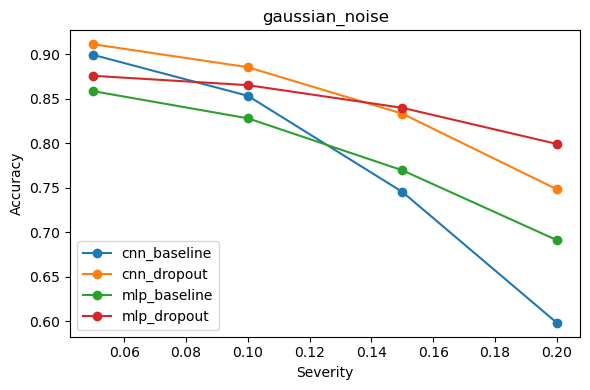

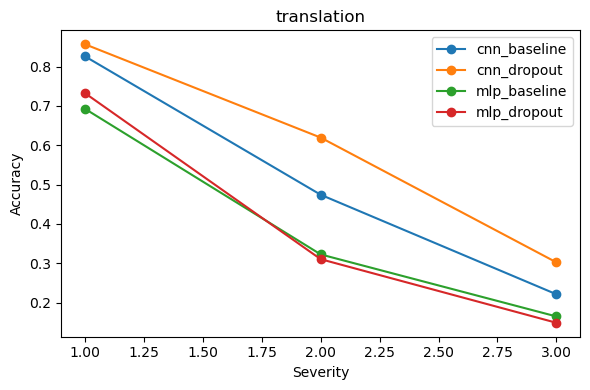

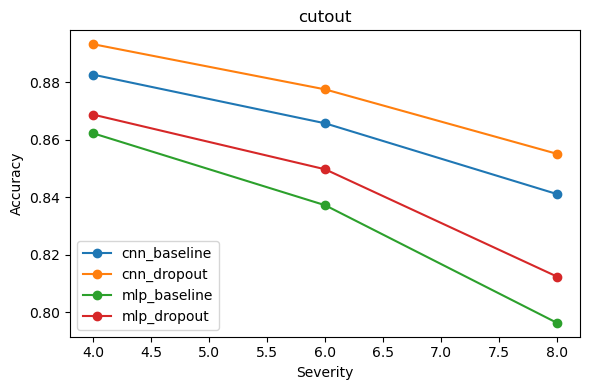

In [39]:
def plot_condition(condition):
    # Filter the global results list down to a single corruption type
    rows = [r for r in results if r["condition"] == condition]
    if not rows:
        print("No rows for condition:", condition)
        return

    models_in = sorted(set(r["model"] for r in rows))
    levels = sorted(set(r["level"] for r in rows)) # Severity levels

    plt.figure(figsize=(6, 4))
    for m in models_in:
        xs = []
        ys = []
        for lvl in levels:
            match = [r for r in rows if r["model"] == m and r["level"] == lvl]
            if match:
                xs.append(lvl)
                ys.append(match[0]["accuracy"])
        plt.plot(xs, ys, marker="o", label=m)

    plt.xlabel("Severity")
    plt.ylabel("Accuracy")
    plt.title(condition)
    plt.legend()
    plt.tight_layout()
    plt.show()
# Plot robustness curves for each perturbation type
for cond in ["gaussian_noise", "translation", "cutout"]:
    plot_condition(cond)

In [40]:
def save_condition_plot(condition, filename):
    # Extract corresponding rows
    rows = [r for r in results if r["condition"] == condition]
    models_in = sorted(set(r["model"] for r in rows))
    levels = sorted(set(r["level"] for r in rows))

    plt.figure(figsize=(6, 4))
    for m in models_in:
        xs, ys = [], []
        for lvl in levels:
            match = [r for r in rows if r["model"] == m and r["level"] == lvl]
            if match:
                xs.append(lvl)
                ys.append(match[0]["accuracy"])
        plt.plot(xs, ys, marker="o", label=m)

    plt.xlabel("Severity")
    plt.ylabel("Accuracy")
    plt.title(condition)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=150)
    plt.close()

save_condition_plot("gaussian_noise", "robustness_noise.png")
save_condition_plot("translation", "robustness_translation.png")
save_condition_plot("cutout", "robustness_cutout.png")
print(f"Saved robustness plots to: {FIG_DIR}")

Saved robustness plots to: outputs\figures
